## Concept Check:

**1. When should you use a bar chart vs. a histogram?**
* **Bar Chart:** Used to compare categorical data, by representing each category with a bar (e.g., comparing total goals across different teams). There are gaps between the bars because the categories are seprate.
* **Histogram:**  Used for continuous numerical data (e.g., analyzing the distribution of player heights).It groups numberical data into continuous ranges or bins, and the bars touch each other because the data flows continuously.

**2. What does a boxplot show that a histogram doesn't?**
* A boxplot explicitly highlights summary statistics like the **median**, **quartiles**, and most importantly, **outliers** (extreme values), which are clearly marked as individual data points.
When comparing multiple group side by side (like regular season vs finals), boxplot allow us to directly compare quartiles and medians cleanly without being distracted by complex overall shapes or messy overlaps that histograms often create.

**3. How do you add labels, title, and legend to a Matplotlib chart?**
* **Title:** `plt.title("Title")`
* **Labels:** `plt.xlabel("X-Axis Label")` and `plt.ylabel("Y-Axis Label")`
* **Legend:** `plt.legend()`

**4. What's a heatmap typically used for in EDA?**
* In Exploratory Data Analysis (EDA), a heatmap is typically used to visualize the **correlation matrix** between multiple numerical variables. It uses color gradients to help identify strong positive or negative relationships at a glance.

**5. Why is a pie chart usually a bad choice for data with more than 4-5 categories?**
* The human eye struggles to accurately compare angles and areas. With too many categories, a pie chart becomes cluttered and hard to interpret. A bar chart is almost always a better, clearer choice for multiple categories.

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load the dataset
df = pd.read_csv("afl_cleaned_dataset.csv")



In [89]:
#  Check for missing values
print(df.isnull().sum())

player_id       0
year            0
team            0
is_finals       0
games_played    0
               ..
last_age        0
height          0
weight          0
player_link     0
player_teams    0
Length: 68, dtype: int64


In [90]:
df.head(2)

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_teams
0,43261,2018,geelong cats,False,3,17.0,9.0,21.0,38.0,3.0,...,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,geelong cats,True,1,3.0,2.0,2.0,5.0,0.0,...,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,"{Geelong Cats,St Kilda Saints}"


# Line Chart

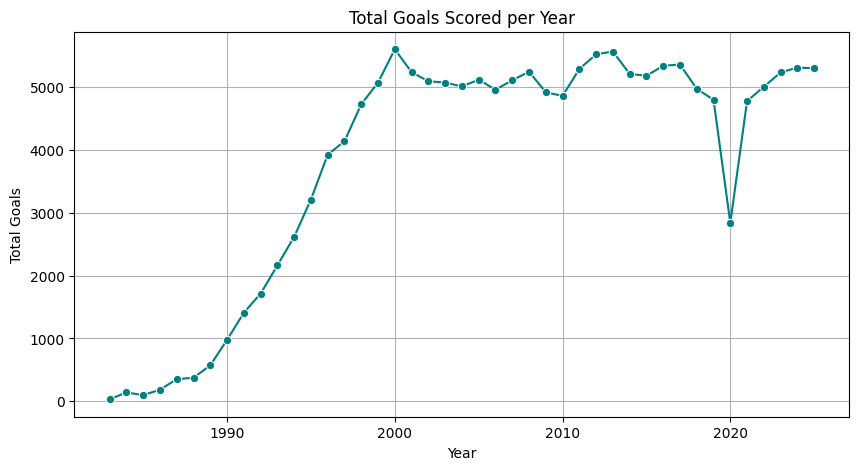

In [91]:
# Group the data by 'year' and sum up the 'goals' for each year
goals_by_year = df.groupby('year')['goals'].sum().reset_index()

# Create the Line Chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=goals_by_year, x='year', y='goals', marker='o', color='teal')

# Add labels and title
plt.title("Total Goals Scored per Year")
plt.xlabel("Year")
plt.ylabel("Total Goals")
plt.grid(True)
plt.show()



**What this tells us:** This chart shows the historical trend of total goals scored in the league, highlighting any scoring booms or dips over the years.

**1990s Expansion:** The sharp increase indicates rapid league growth and expansion.

**2000-2019 Stability:** Goals stabilized, consistently remaining between 4,500 and 5,500 per year.

**2020 Anomaly:** The massive drop to ~2,500 goals reflects season disruptions due to COVID-19.

# Bar Chart

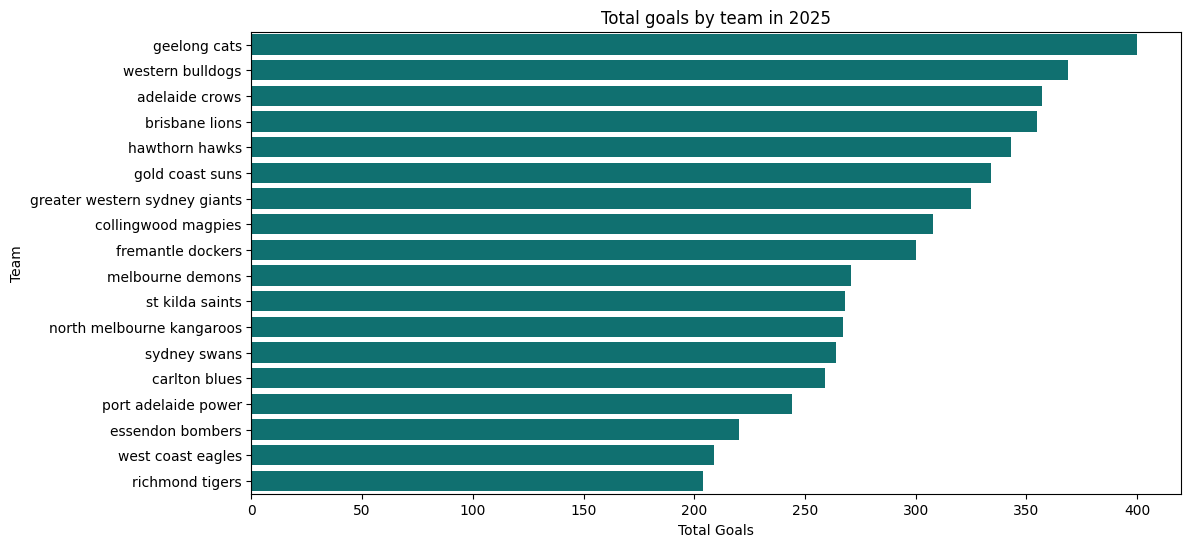

In [100]:
# highest goal of team in 2025
df_2025 = df[df['year']==2025]
# df_2025
team_goal=df_2025.groupby('team')['goals'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=team_goals, x='goals', y='team', color='teal')
plt.title('Total goals by team in 2025')
plt.xlabel("Total Goals")
plt.ylabel("Team")
plt.show()

 **What this tells us:** This chart reveals which teams were the highest scoring offensive powerhouses during the 2025 season, making it easy to rank them from first to last.

**Top Performers:** Geelong Cats dominated the season offensively, leading the league with well over 400 goals.

**Lowest Scorers:** Richmond Tigers struggled the most, finishing at the bottom with approximately 200 goals.

**Performance Gap:** There is a significant disparity in team capabilities, with the top-ranked team scoring roughly double the goals of the lowest-ranked team.

# Histogram

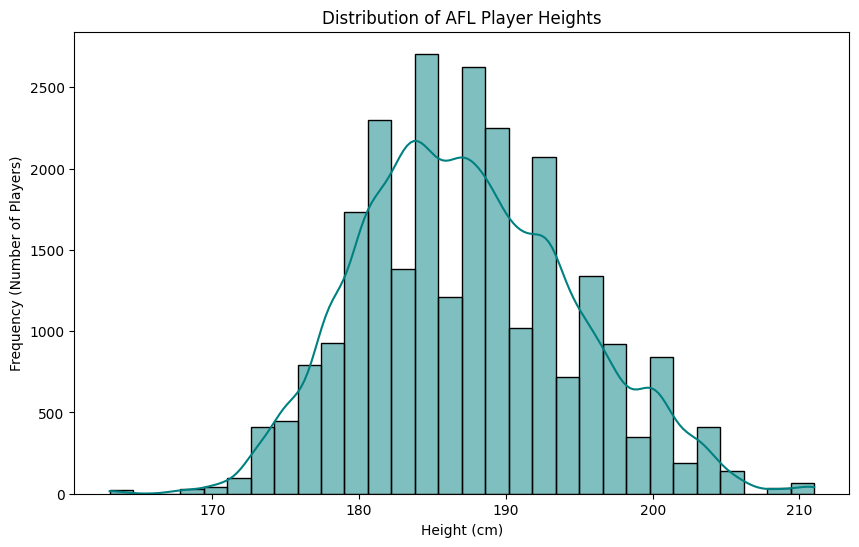

In [93]:

#  Create the Histogram for player heights
plt.figure(figsize=(10, 6))

# bins=30 divides the heights into 30 distinct ranges
# kde=True adds that smooth 'Kernel Density Estimate' line over the bars to show the general shape
sns.histplot(data=df, x='height', bins=30, kde=True, color='teal')

# 3. Add labels and title
plt.title("Distribution of AFL Player Heights")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency (Number of Players)")
plt.show()

**What this tells us:** This chart illustrates the distribution of player heights, revealing that the majority of players cluster around 185cm to 190cm.


# Boxplot

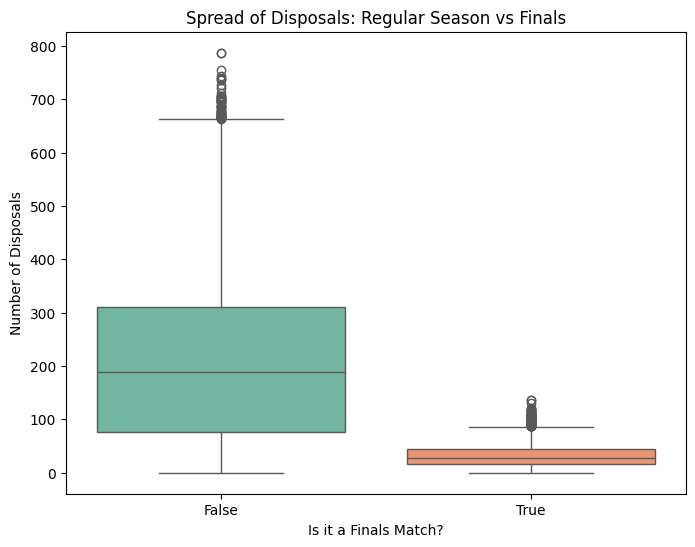

In [94]:

#  Create the Boxplot
plt.figure(figsize=(8, 6))

# We put the category (True/False) on the X-axis, and the numerical stat on the Y-axis
sns.boxplot(data=df, x='is_finals', y='disposals', palette='Set2', hue='is_finals', legend=False)

# Add labels and title
plt.title("Spread of Disposals: Regular Season vs Finals")
plt.xlabel("Is it a Finals Match?")
plt.ylabel("Number of Disposals")
plt.show()

**What this tells us:** This chart displays the median and spread of disposals, The regular season has a significantly higher volume compared to the finals and contain significantly more extreme high-performing outliers.

**Volume Difference:** Regular season disposals are naturally much higher because players play far more matches than in the short finals campaign.

**High Variance:** The large green box shows a massive gap in performance between average players and top players during the regular season.

**Outliers:** The black dots highlight elite players who achieved exceptionally high disposal counts (up to 800) over the full year.

# Scatter Plot

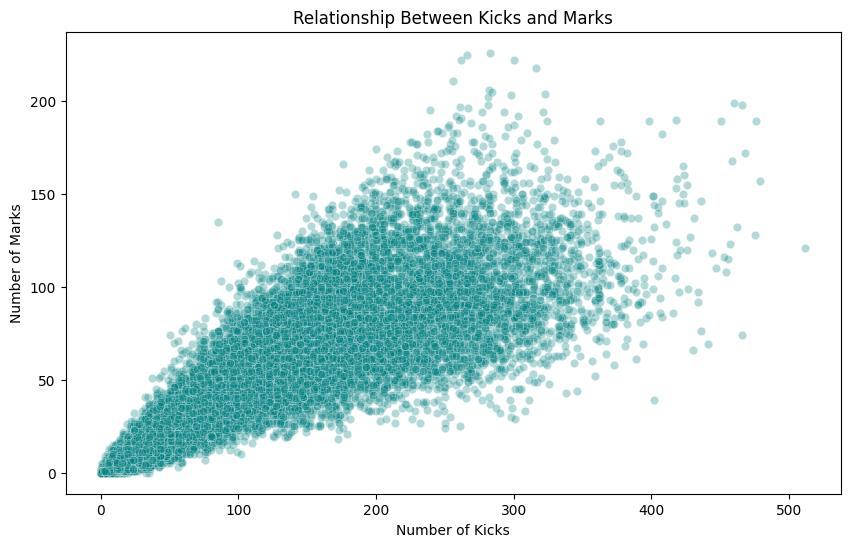

In [95]:

#  Create the Scatter Plot
plt.figure(figsize=(10, 6))

# We use alpha=0.3 to make the dots slightly transparent.
# Since we have 25,000+ rows, this helps us see where the data overlaps the most!
sns.scatterplot(data=df, x='kicks', y='marks', alpha=0.3, color='teal')

#  Add labels and title
plt.title("Relationship Between Kicks and Marks")
plt.xlabel("Number of Kicks")
plt.ylabel("Number of Marks")
plt.show()

**What this tells us:** This chart shows a positive correlation between kicks and marks; generally, players who record more kicks also tend to record more marks.

# Heatmap

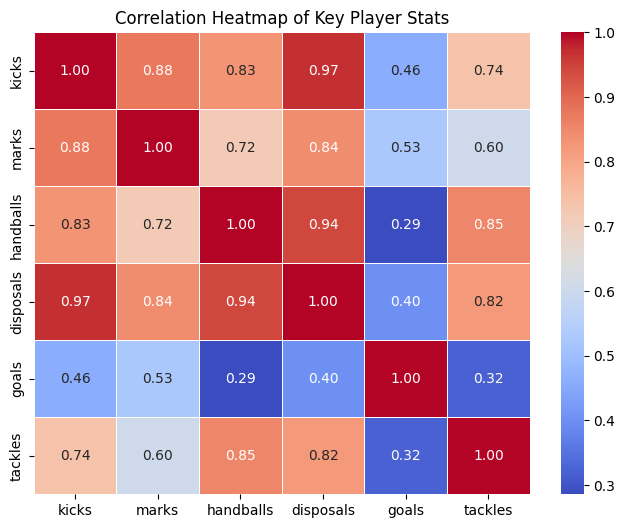

In [96]:

#  Select a specific subset of numerical columns to keep the chart readable
cols_to_compare = ['kicks', 'marks', 'handballs', 'disposals', 'goals', 'tackles']
df_subset = df[cols_to_compare]

#  Calculate the correlation matrix
corr_matrix = df_subset.corr()

#  Create the Heatmap
plt.figure(figsize=(8, 6))

# annot=True puts the actual decimal numbers inside the boxes
# cmap='coolwarm' uses blue for negative correlation and red for positive
# fmt=".2f" rounds the numbers to two decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add a title
plt.title("Correlation Heatmap of Key Player Stats")
plt.show()

 **What this tells us:** This chart reveals how strongly different gameplay statistics correlate; for example, 'disposals' perfectly correlates with 'handballs' and 'kicks' because a disposal is just the sum of the two.

